IMPORT REQUIRED LIBRARIES





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA


LOAD THE DATASET

In [2]:
from io import StringIO
import re

file_path = '/content/KDDTest+.arff'

# Read the entire ARFF file content
with open(file_path, 'r', encoding='utf-8') as f:
    arff_content = f.read()


fixed_arff_content = arff_content.replace(" 'icmp'", "icmp")

# Create a file-like object from the modified content
arff_file_obj = StringIO(fixed_arff_content)

# Load ARFF file from the file-like object
data, meta = arff.loadarff(arff_file_obj)

# Convert to DataFrame
df = pd.DataFrame(data)

# Decode byte columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,10.0,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,1.0,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,2.0,tcp,ftp_data,SF,12983.0,0.0,0,0.0,0.0,0.0,...,86.0,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0.0,icmp,eco_i,SF,20.0,0.0,0,0.0,0.0,0.0,...,57.0,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,1.0,tcp,telnet,RSTO,0.0,15.0,0,0.0,0.0,0.0,...,86.0,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


BASIC DATA UNDERSTANDING

In [17]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Class distribution - absolute numbers
class_counts = df['class'].value_counts()

# Class distribution - percentage
class_percent = df['class'].value_counts(normalize=True) * 100

print("\nClass Distribution (Percentage with Absolute Numbers):")

for cls in class_counts.index:
    print(f"{cls}: {class_percent[cls]:.2f}% ({class_counts[cls]})")


Dataset Shape: (22544, 42)

Class Distribution (Percentage with Absolute Numbers):
0: 56.92% (12833)
1: 43.08% (9711)


DATA PROCESSING


4.1 Encode Categorical Variables

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


4.2 Feature–Target Split

In [5]:
X = df.drop('class', axis=1)
y = df['class']


4.3 Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


EDA

5.1 Attack vs Normal Traffic

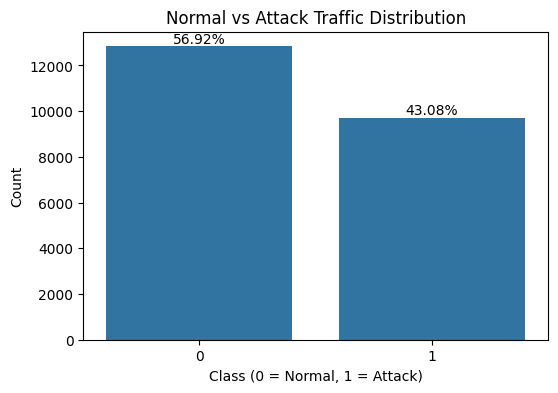

In [24]:
# Count & percentage
class_counts = y.value_counts()
class_percent = y.value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y)

plt.title("Normal vs Attack Traffic Distribution")
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Count")

# Add percentage labels
for i in range(len(class_counts)):
    count = class_counts[i]
    percent = class_percent[i]

    ax.text(i,
            count,
            f"{percent:.2f}%",
            ha='center',
            va='bottom')

plt.show()

5.2 Pair Plot (Best for Feature Relationships)

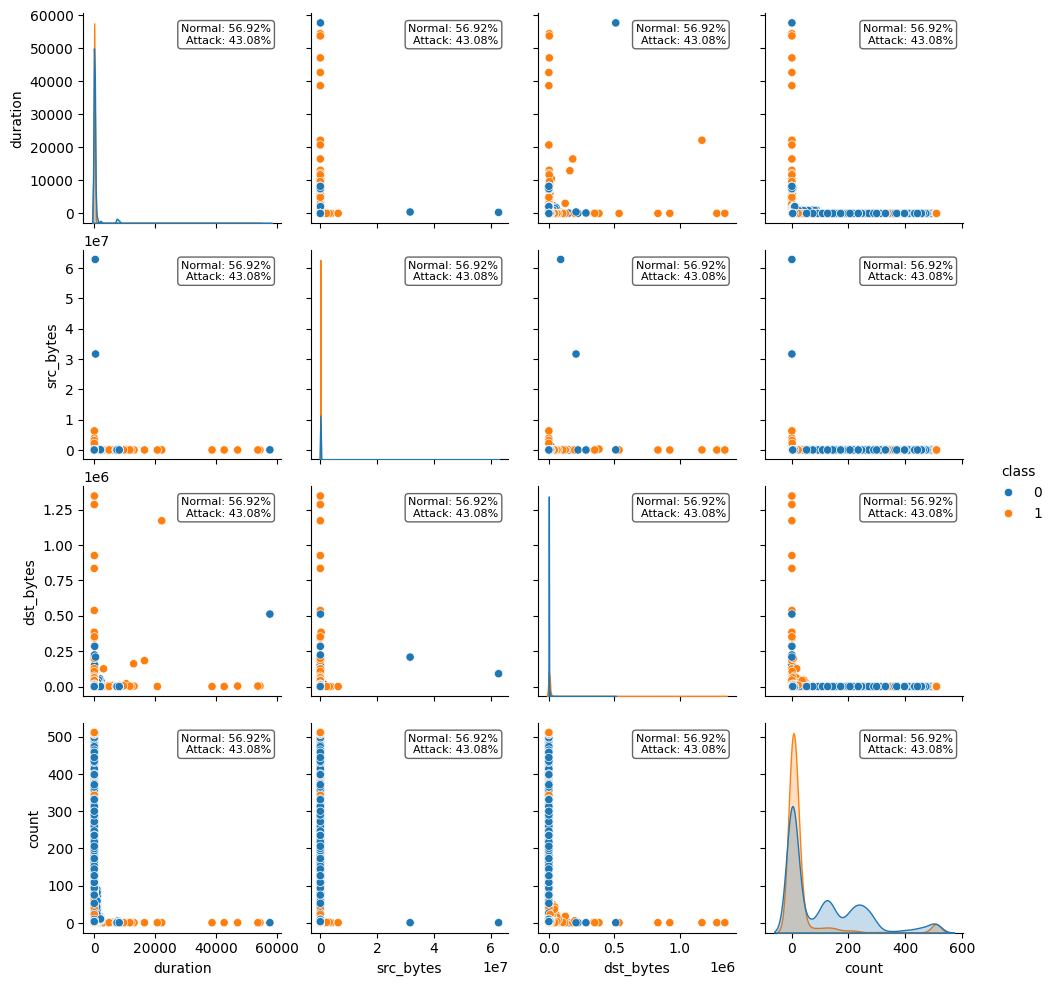

In [25]:
# Calculate percentages
class_percent = df['class'].value_counts(normalize=True) * 100

normal_pct = class_percent[0]
attack_pct = class_percent[1]

# Pairplot
g = sns.pairplot(
    df[['duration', 'src_bytes', 'dst_bytes', 'count', 'class']],
    hue='class',
    diag_kind='kde'
)

# Annotation text
text_label = f"Normal: {normal_pct:.2f}%\nAttack: {attack_pct:.2f}%"

# Add text to each subplot (top-right corner)
for ax in g.axes.flatten():
    if ax is not None:
        ax.text(
            0.95, 0.95,                 # Top-right position
            text_label,
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
        )

plt.show()


ANOMALY VISUALISATION USING PCA

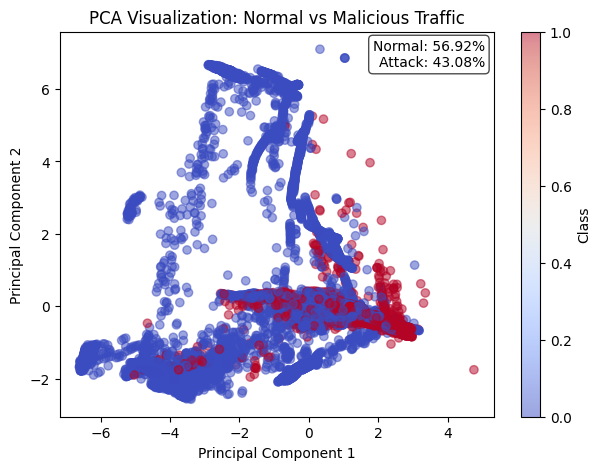

In [26]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calculate percentages
class_percent = pd.Series(y).value_counts(normalize=True) * 100
normal_pct = class_percent[0]
attack_pct = class_percent[1]

# Plot
plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.5
)

plt.title("PCA Visualization: Normal vs Malicious Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Class")

# Text to display
text_label = f"Normal: {normal_pct:.2f}%\nAttack: {attack_pct:.2f}%"

# Add annotation (top-right)
plt.text(
    0.98, 0.98,
    text_label,
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.show()


ML MODEL - THREAT DETECTION

7.1 Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


7.2 Random Forest Classifier

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

MODEL EVALUATION

In [19]:
from sklearn.metrics import classification_report

# Predictions
y_pred = rf.predict(X_test)

# Get report as dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

print("Classification Report (Percentage with Absolute Numbers):\n")

for label, metrics in report_dict.items():

    # Handle accuracy separately
    if label == "accuracy":
        total_samples = len(y_test)
        correct_preds = int(metrics * total_samples)
        print(f"\nAccuracy: {metrics*100:.2f}% ({correct_preds}/{total_samples})")
        continue

    # Skip macro & weighted averages
    if label in ["macro avg", "weighted avg"]:
        continue

    # Class-wise metrics
    support = int(metrics["support"])

    print(f"\nClass: {label}")
    print(f"Precision: {metrics['precision']*100:.2f}% ({support})")
    print(f"Recall:    {metrics['recall']*100:.2f}% ({support})")
    print(f"F1-score:  {metrics['f1-score']*100:.2f}% ({support})")




Classification Report (Percentage with Absolute Numbers):


Class: 0
Precision: 98.78% (3850)
Recall:    98.96% (3850)
F1-score:  98.87% (3850)

Class: 1
Precision: 98.62% (2914)
Recall:    98.39% (2914)
F1-score:  98.51% (2914)

Accuracy: 98.71% (6677/6764)


CONFUSION MATRIX

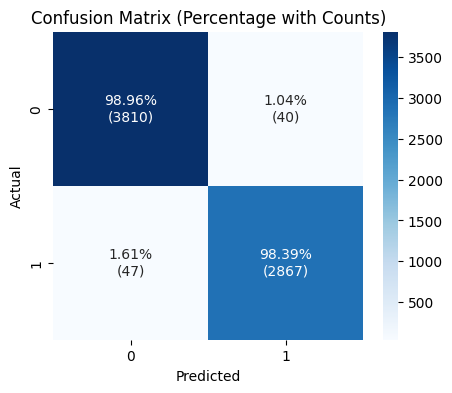

In [20]:
cm = confusion_matrix(y_test, y_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels -> "percent (count)"
labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        labels[i, j] = f"{cm_percent[i, j]:.2f}%\n({cm[i, j]})"

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=labels,
            fmt="",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Percentage with Counts)")
plt.show()


SECURITY INSIGHTS

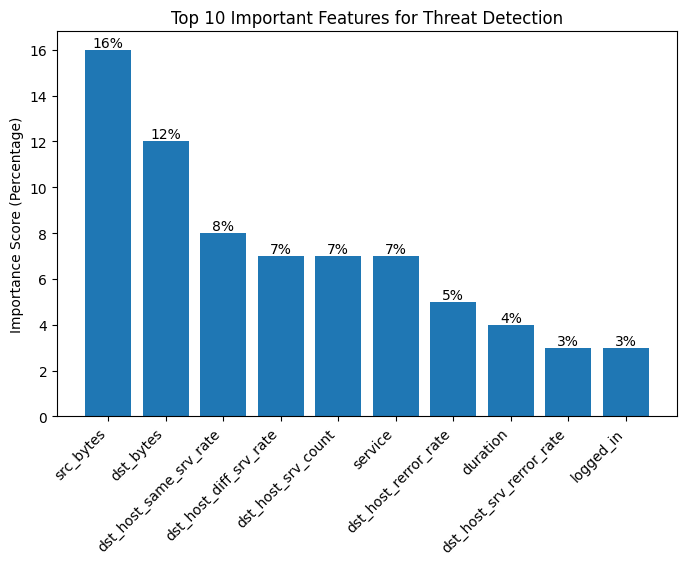

In [21]:
# Top 10 feature importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

# Convert to percentage & whole numbers
feature_importance_percent = (feature_importance * 100).round(0)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(feature_importance_percent.index,
               feature_importance_percent.values)

plt.title("Top 10 Important Features for Threat Detection")
plt.ylabel("Importance Score (Percentage)")
plt.xticks(rotation=45, ha="right")

# Add % labels on bars
for bar, value in zip(bars, feature_importance_percent.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{int(value)}%",
             ha='center',
             va='bottom')

plt.show()
